# TP ALOHA - CSMA pour TELECOM204

**Student Version**

*31* Mai 2021  (Enseignant: Anastasios GIOVANIDIS)

L'objectif de ces travaux partiques est de vérifier par simulation les résultats analytiques vus en cours sur les performances des algorithmes d'accès aléatoire. À chaque section correspond un canevas de code en Python.
Vous devez remplir les parties de code manquantes et exécuter le programme obtenu, comme indiqué.

**Résultats.**

Notez les fonctions complétées et les résultats obtenus au fur et à mesure.

Le code rempli avec vos reponses est à envoyer en format Jupyter-notebook (.ipynb) avant le **01 Juin 2020, 23h59** à mon adresse mail:

anastasios.giovanidis@lip6.fr

avec votre nom comme nom de fichier: votrenom.pdf

**Votre NOM Prenom ici:** HUBER Blaise



In [3]:
import numpy as np
from numpy.random import binomial
import matplotlib.pyplot as plt

## Exercise 1: ALOHA synchrone

On s'intéresse d'abord à la performance du protocole d'accès aléatoire ALOHA synchrone. On considère $N$ stations partageant un meme canal de transmission. Chaque station est supposée d'avoir un nombre infini de paquets à transmettre.

Dans le protocole ALOHA les transmissions sont aveugles et chaque station émet indépendamment de l'état des autres stations. Par convention, la durée d'un slot est alors égale au temps de transmission d'un paquet.

Dans chaque slot, chaque station émet avec une probabilité fixe $p$, indépendamment des autres stations. En mode synchrone, un slot est utile si et seulement si une seule station émet sur ce slot.

1. Quelle est la probabilité qu'un slot soit utile?

2. Quelle est la probabilité d'emission optimale, $p^*$?

3. En vue des deux questions précedentes, quel est le taux d'utilisation atteint par ALOHA synchrone?

Evaluez aussi les reponses 2,3 pour le cas $N=5$.

**Answer 1,2,3**

1. On choisit une station parmi N. Cette station émet un paquet (probabilité p) et les N-1 autres stations n'émettent pas de paquet (probabilité 1-p). On a donc :
$u = N p (1-p)^{N-1}$

2. On dérive u et on cherche le maximum (point d'annulation de la dérivée). On obtient alors la probabilité optimale : $p^* = \frac{1}{N}$

3. Dans le cas de l'Aloha synchrone, le taux d'utilisation maximal $U^*$ est égal à la probabilité optimale qu'une seule station n'émette $u^* = (1-\frac{1}{N})^{N-1}$. Ce taux d'utilisation max tend vers $\frac{1}{e}$ lorsque N tend vers l'infini.

Dans le cas N=5, on a :

-  $p^* = \frac{1}{5}$

- $u^* = (1-\frac{1}{5})^{5-1} = (\frac{4}{5})^4 = \frac{256}{625} = 0,41 $


4. Complétez le programme de simulation permettant d'estimer le taux d'utilisation (throughput) atteint par ALOHA synchrone.

In [3]:
#Parameters
N = 5                #total number of users
p_test = 0.1         #an example value for the probability p
#
# Simulation Time
t_max = 10000        #simulation time in number of slots
t_vec = np.arange(0,t_max)
#
# A vector of probability choices
p_step = 0.01                            #probability step
p_vec = np.arange(0,1+p_step,p_step)     #Vector of values for the transmission probability
#

In [4]:
# Initialize global
throughput = list()  #resulting throughput vector
#
for p in p_vec:
    # Initialize local
    nb_packets = 0       #cumulative number of successfully transmitted packets

    for t in t_vec:
      ListePackets=[binomial(1,p) for n in range(N)] #chaque station n émet un paquet(1) avec une proba p

      if sum(ListePackets) == 1 : #un seul paquet a été transmis, sinon on a soit un slot vide ou une collision
        nb_packets += 1

    u = nb_packets/t_max
    throughput.append(u)

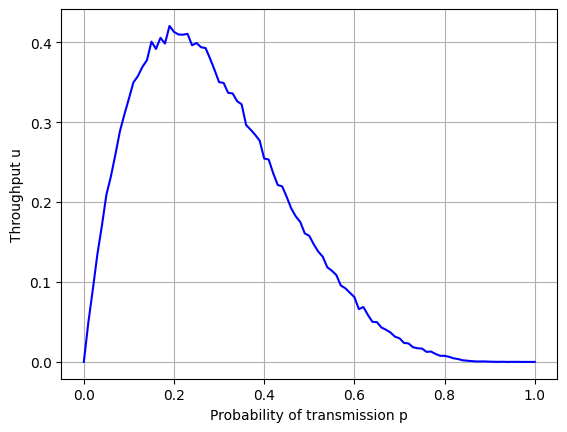

In [5]:
plt.plot(p_vec, throughput, 'b-')
plt.xlabel('Probability of transmission p')
plt.ylabel('Throughput u')
plt.grid()
plt.show()

In [6]:
#p_opt = ?
u_max = max(throughput)
ind_u_max = throughput.index(u_max)
p_opt = p_vec[ind_u_max]
print("p_opt =", p_opt)
print("u_max =", u_max)

p_opt = 0.19
u_max = 0.4205


5. Comparez les résultats analytiques avec eux des simulations, concernant le taux d'utilisation.

**Answer 5**

Les réslutats expérimentaux confirment bien les résultats analytiques :

 - On trouve un $p_{opt}=0,2$ ce qui confirme bien lla théorie $p^* = \frac{1}{5}$
 - On trouve $u_{max}=0,4174$ ce qui confirme églement bien la théorie $u^* = 0,41$ environ.

6. Expliquez les résultats obtenus pour $N=5$ stations et différentes valeurs de $p$.

Pour N = 5 stations, les différentes valeurs de p mettent en évidence trois zones:

- Pour p < 0,2 : Sous-utilisation : le débit est faible car les stations émettent trop rarement, laissant le canal souvent inoccupé

- Pour p = 0,2 : Le débit est maximal ($u =0,417$). Cela valide parfaitement la théorie qui prédit un optimum à $p^* = \frac{1}{5}$. C'est le point d'équilibre où la probabilité qu'une unique station émette est maximale.

- Pour p > 0,2 : Le débit chute rapidement à cause de l'augmentation des collisions. Lorsque $p \to 1$, toutes les stations émettent en même temps à chaque slot et le canal est donc saturé de collisions, plus aucun paquet n'est transmis avec succès (u=0)

7. Qu'est-ce qu'on constate pour le taux d'utilisation (throughput) si on garde la probabilité de transmission optimale pour $N=5$, mais on varie le nombre des utilisateurs presents, entre $\{1,\ldots, 20\}$?

Pour repondre, modifiez le code de Question 4, pour $p^*$ fix et $N$ qui varie.

In [7]:
#Parameters
N_vec = np.arange(1,21)
p_test = 0.1         #an example value for the probability p
#
# Simulation Time
t_max = 10000        #simulation time in number of slots
t_vec = np.arange(0,t_max)
#
# A vector of probability choices
p = 0.2  #probabilité optimale pour N=5 stations
#

# Initialize global
throughput_N = list()  #resulting throughput vector
#
for N in N_vec:
    # Initialize local
    nb_packets = 0       #cumulative number of successfully transmitted packets

    for t in t_vec:
      ListePackets=[binomial(1,p) for n in range(N)] #chaque station n émet un paquet(1) avec une proba p

      if sum(ListePackets) == 1 : #un seul paquet a été transmis, sinon on a soit un slot vide ou une collision
        nb_packets += 1

    u = nb_packets/t_max
    throughput_N.append(u)

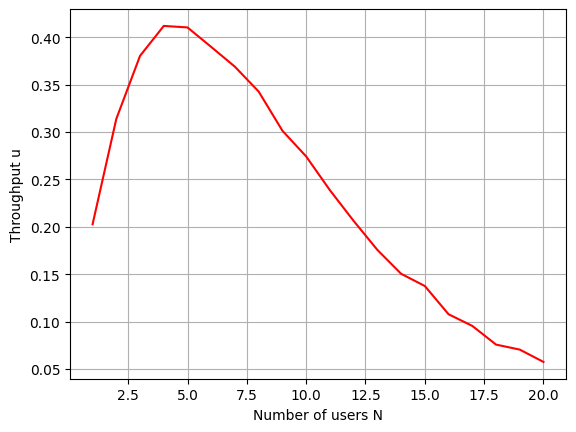

In [8]:
plt.plot(N_vec, throughput_N, 'r-')
plt.xlabel('Number of users N')
plt.ylabel('Throughput u')
plt.grid()
plt.show()

Si on fixe la probabilité de transmission à la valeur optimale pour N = 5 (soit p = 0,2), on observe trois phases sur le graphique :
- Pour N < 5 : Sous-utilisation : Le débit augmente avec le nombre d'utilisateurs. En effet, il n'y a pas beaucoup de stations qui émettent donc le canal reste souvent vide.
- Pour N = 5: Maximum : Le débit atteint son sommet (u = 0,41). En effet, le nombre de stations correspond parfaitement à la probabilité fixée (p = 1/N).
- Pour N > 5 : Effondrement par collisions : Le débit chute rapidement à mesure que N augmente, En effet, le trop grand nombre d'utilisateurs provoque une multiplication des collisions sur le canal, qui ne transmet alors quasi plus rien pour N=20.

En conclusion : Une probabilité fixe de 0,2 ne permet pas au protocole de s'adapter. Dès que le nombre d'utilisateurs s'éloigne de 5, l'efficacité du réseau s'effondre.

8. Montrez avec une simulation comment le taux d'utilisation optimal (optimal throughput) change avec le nombre des utilisateurs presents, entre $\{1,\ldots, 20\}$? Quelle est la valeur de taux a la limite?

Pour repondre, modifiez le code de Question 7, pour $p[N] = p_{opt}[N]$ ou la probablite change en fonciton de N.

In [13]:
# Initialize global
throughput_opt_N = list()  #resulting optimal throughput vector
# p_opt_vec =??
#Parameters
N_vec = np.arange(1,21)
p_test = 0.1         #an example value for the probability p
#
# Simulation Time
t_max = 10000        #simulation time in number of slots
t_vec = np.arange(0,t_max)
#
# A vector of probability choices
p = [1/n for n in range(1, 21)]  #probabilité optimale pour N=5 stations
p_opt = [0]+p
#

for N in N_vec:
    # Initialize local
    nb_packets = 0       #cumulative number of successfully transmitted packets

    for t in t_vec:
      ListePackets=[binomial(1,p_opt[N]) for n in range(N)] #chaque station n émet un paquet(1) avec une proba p

      if sum(ListePackets) == 1 : #un seul paquet a été transmis, sinon on a soit un slot vide ou une collision
        nb_packets += 1

    u = nb_packets/t_max
    throughput_opt_N.append(u)

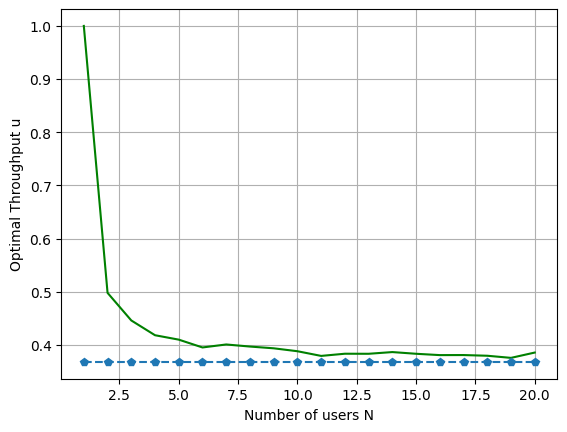

In [14]:
plt.plot(N_vec, throughput_opt_N, 'g-')
plt.plot(N_vec,np.ones(len(N_vec))*np.exp(-1), 'p--')
plt.xlabel('Number of users N')
plt.ylabel('Optimal Throughput u')
plt.grid()
plt.show()

Pour N = 1, le débit optimal est de 1 car le canal est utilisé en entier sans aucune collision.

À mesure que le nombre d'utilisateurs N augmente, le débit optimal décroît rapidement, et tend vers une valeur de 1/e représentée par la ligne en pointillées bleus.

Cette courbe expérimentale confirme ainsi la valeur théorique du débit optimal pour N qui tend vers l'infini : d'après la question 3, le taux d'utilisation maximal est $u = (1 - \frac{1}{N})^{N-1}$ qui tend vers $\frac{1}{e}$ lorsque $N \to \infty$.

## Exercise 2: ALOHA adaptatif

On considère maintenant un algorithme adaptatif où la probabilité d'emission dépend du nombre de collisions déjà subies. Plus spécifiquement, la probabilité d'emission d'une station est divisée par 2 à chaque collision. On note $p0$ la probabilité d'emission initiale, à la premiére tentative de transmission d'un paquet. On considère le mode synchrone.

1-2. Complétez le programme de simulation permettant d'estimer le débit total du système. Exécutez le programme avec $p0 = 0.2$ et interprétez les résultats.

(*) Question: Quel est le comportement du système quand le nombre N des utilisateurs augmente, avec p0 fixe?

In [15]:
#Parameters
t_max = 10000    #= 1000000       #Simulation time  (with longer option)
t_vec = np.arange(0,t_max)
#
N_max = 20;             #Maximum number of users
N_vec = np.arange(1,N_max+1)
p0 = 0.2

In [24]:
# Initialize global
throughput_A_N = list()
pp_av = list()    # for Question 4
#
for N in N_vec:
    # Initialize local
    nb_packets_A = 0       #cumulative number of successfully transmitted packets
    nb_efforts = np.zeros(N)   # vecteur avec le nombre de collision par station
    nb_collisions = 0          # nombre cumulatif de collisions
    p_av = np.zeros(N)

    for t in t_vec:
        p = p0/2**nb_efforts  #vecteur des probabilités d'émission pour chaque station
        p_av = p_av + p
        ListePaquets=np.array([binomial(1,p[n]) for n in range(N)]) #chaque station n émet un paquet(1) avec une proba p0

        if sum(ListePaquets) == 1 : #un seul paquet a été transmis
            nb_packets_A += 1
            indice_1 = np.where(ListePaquets == 1)[0][0]
            nb_efforts[indice_1] = 0   # le user retourne à un nombre d'efforts de 0, don à la probabilité p0
        else:                       #slot vide ou collision
            nb_collisions += 1
            nb_efforts = nb_efforts + ListePaquets # on ajoute 1 effort pour chaque station qui a transmis (et qui subit donc une collision)

    u = nb_packets_A/t_max
    p_av = p_av/t_max      # for Question 4
    pp_av.append(sum(p_av)/N)   # for Question 4
    throughput_A_N.append(u)

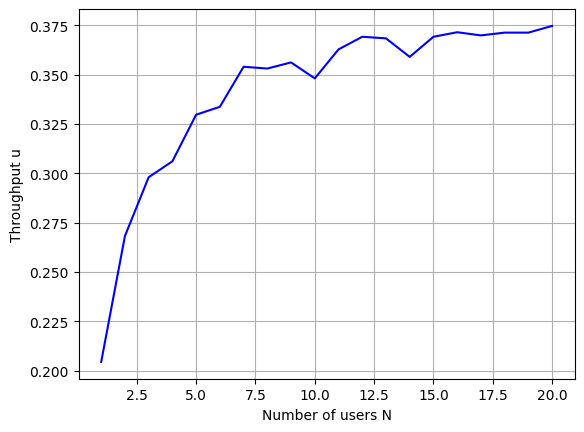

In [19]:
plt.plot(N_vec, throughput_A_N, 'b-')
plt.xlabel('Number of users N')
plt.ylabel('Throughput u')
plt.grid()
plt.show()

On observe tout d'abord le le throughput u augmente avec le nombre d'utilisateurs N, même pour des valeurs de N très grandes, ce qui est une première !

Contrairement au protocole non adaptatif où le débit s'effondrait vers 0 à cause des collisions, cet algorithme adaptatif permet de maintenir un débit stable et non nul, même lorsque N devient grand.

En effet, plus N augmente, plus le risque initial de collision est fort. Mais, dès qu'une collision survient, les stations divisent leur probabilité d'émission par 2 et le système régule la charge globale sur le canal pour atteindre un niveau proche de l'optimum théorique, évitant ainsi la saturation complète du réseau.

3. Comparez le debit total adaptatif avec le résultat obtenu dans le cas ALOHA synchrone, pour $N = 2$, $N = 5$, $N = 20$. Quels sont vos conclusions?

Lorsqu'on fixe p=0,2 dans le cas de l'Aloha synchrone (question 5 de l'exercice 1), on a alors les valeurs suivantes de throughput u en fonction de N:
- N = 2: u = 0,3
- N = 5: **u = 0,41**
- N = 20: u = 0,06

Dans le cas de l'Aloha adaptatif, on a les valurs suivantes:
- N = 2: u = 0,275
- N = 5: u = 0,33
- N = 20: **u = 0,375**

On observe que pour N < 5, le throughput est meilleur dans le cas de l'Aloha Synchrone, mais que pour N > 5, il est meilleur dans le cas de l'Aloha Adaptatif.

On remarque également que le throughput maximal de l'Aloha Synchrone (0,41) est meilleur que celui de l'Aloha Adaptatif (0,375).

Néanmoins, le throughput de l'Aloha Synchrone n'est satisfaisant que pour une **petite plage de valeurs de N**, et **très mauvais pour un N grand**, alors que le throuput de l'Aloha Adaptatif est **satisfaisant quel que soit la valeur de N**, particulièrement pour des valeurs de N grandes.

En conclusion, on peut dire que si l'on connait exactement le nombre de stations (ce qui est rare), il vaut mieux utiliser l'Aloha Synchrone, mais si on ne connaît pas précisément le nombre de stations (cas le plus courant), il faut utiliser l'Aloha Adaptatif.


4. Fixez $p0=0.2$ et $N=[1,...,Nmax]$. Empiriquement, si

$\overline{p} = \frac{1}{N\cdot T}\sum_{t=1}^{T}\sum_{n=1}^N p_{t,n}$

est la probabilité moyenne de transmission par utilisateur, comparez avec $p^∗[N]=1/N$ (ALOHA synchrone).
Expliquez vos observations, aussi par rapport au débit total.

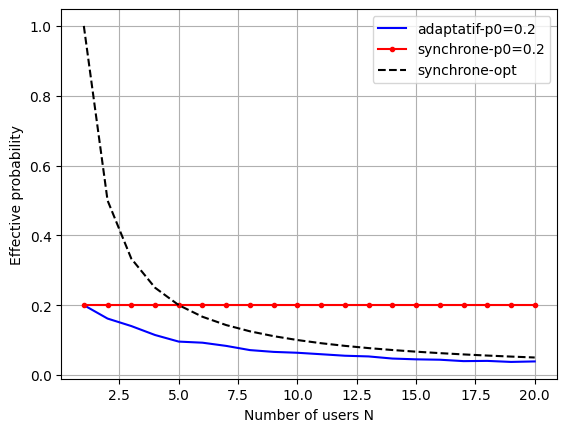

In [25]:
plt.plot(N_vec, pp_av, 'b-',label='adaptatif-p0=0.2')
plt.plot(N_vec, p0*np.ones(len(N_vec)),'r.-',label='synchrone-p0=0.2')
plt.plot(N_vec, 1/N_vec, 'k--',label='synchrone-opt')
plt.ylabel('Effective probability')
plt.xlabel('Number of users N')
plt.legend()
plt.grid()
plt.show()

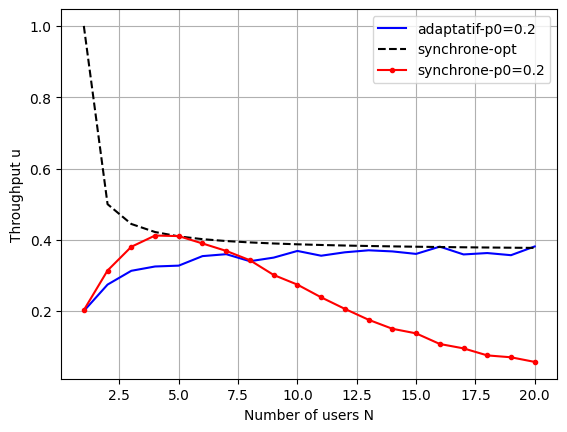

In [27]:
AlohaS = (1-1/N_vec)**(N_vec-1)
plt.plot(N_vec, throughput_A_N, 'b-',label='adaptatif-p0=0.2')
plt.plot(N_vec,AlohaS, 'k--',label='synchrone-opt')
plt.plot(N_vec,throughput_N,'r.-',label='synchrone-p0=0.2')
plt.ylabel('Throughput u')
plt.xlabel('Number of users N')
plt.legend()
plt.grid()
plt.show()

**Courbes de probabilités:**


L'Aloha synchrone optimal (courbe noire) reflète une adaptation parfaite mais idéale (on ne connait pas le nomre exact de stations), où chaque utilisateur ajuste sa probabilité de transmission pour éviter les collisions.

On a ensuite deux modélisations plus réalistes:
- l'Aloha synchrone avec une probabilité fixe p=0.2 (courbe rouge)
- l'Aloha adaptatif (courbe bleue) avec une probabilité moyenne qui décroit en fonction de N, mais moins rapidement que pour l'ALOHA synchrone optimal.

On remarque alors que la courbe bleue se rapproche de plus en plus de la courbe idéale noire lorsque N augmente : **l'Aloha adaptatif se rapproche de la probabilité optimale.**

**Courbes de débit:**

Encore une fois, la courbe noire de l'Aloha synchrone optimal maximise le débit, mais c'est une modélisation un peu idéaliste.
Le but des deux modèles réalistes est alors de se rapprocher le plus possible de cette courbe noire
- pour l'Aloha synchrone avec une proba fixée à p=0.2 (courbe rouge), le débit se rapproche de la courbe noire pour des faibles valeurs de N et atteint la valeur optimale pour N=5. Mais ensuite, pour des plus grandes valeurs de N le débit s'effondre à cause d'un trop grand nombre de collisions.
- pour l'Aloha adaptatif (courbe bleue), le débit est assez inférieur à la courbe noire pour des faibles valeurs de N, mais ensuite la courbe bleue se raproche de plus en plus de la courbe noire pour des grandes valeurs de N : **le débit de l'Aloha adaptatif se rapproche du débit optimal.**

5. Que se passe-t-il lorsque $p0 = 1$? Expliquez ce phénomène.

In [4]:
#Parameters
t_max = 10000    #= 1000000       #Simulation time  (with longer option)
t_vec = np.arange(0,t_max)
#
N_max = 20;             #Maximum number of users
N_vec = np.arange(1,N_max+1)
p0 = 1

# Initialize global
throughput_A_N = list()
pp_av = list()    # for Question 4
#
for N in N_vec:
    # Initialize local
    nb_packets_A = 0       #cumulative number of successfully transmitted packets
    nb_efforts = np.zeros(N)   # vecteur avec le nombre de collision par station
    nb_collisions = 0          # nombre cumulatif de collisions
    p_av = np.zeros(N)

    for t in t_vec:
        p = p0/2**nb_efforts  #vecteur des probabilités d'émission pour chaque station
        p_av = p_av + p
        ListePaquets=np.array([binomial(1,p[n]) for n in range(N)]) #chaque station n émet un paquet(1) avec une proba p0

        if sum(ListePaquets) == 1 : #un seul paquet a été transmis
            nb_packets_A += 1
            indice_1 = np.where(ListePaquets == 1)[0][0]
            nb_efforts[indice_1] = 0   # le user retourne à un nombre d'efforts de 0, don à la probabilité p0
        else:                       #slot vide ou collision
            nb_collisions += 1
            nb_efforts = nb_efforts + ListePaquets # on ajoute 1 effort pour chaque station qui a transmis (et qui subit donc une collision)

    u = nb_packets_A/t_max
    p_av = p_av/t_max      # for Question 4
    pp_av.append(sum(p_av)/N)   # for Question 4
    throughput_A_N.append(u)

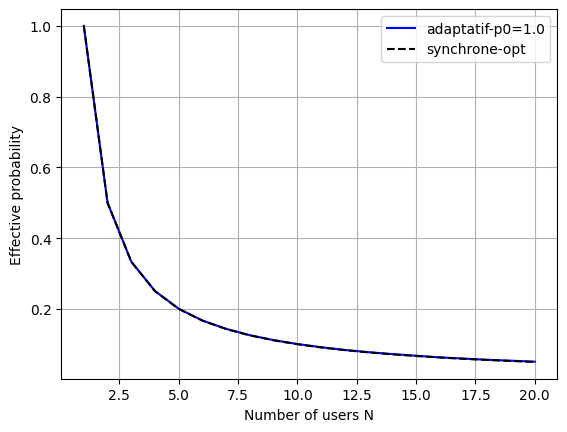

In [5]:
plt.plot(N_vec, pp_av, 'b-',label='adaptatif-p0=1.0')
#plt.plot(N_vec, p0*np.ones(len(N_vec)),'r.-',label='synchrone-p0=1.0')
plt.plot(N_vec, 1/N_vec, 'k--',label='synchrone-opt')
plt.ylabel('Effective probability')
plt.xlabel('Number of users N')
plt.legend()
plt.grid()
plt.show()

Pour p0 = 1, la probabilité moyenne de l'Aloha adaptatif correspond exactement la probabilité de l'Aloha synchrone optimal !
L'Aloha adaptatif converge donc vers l'algorithme d'Aloha synchrone optimal.

En effet, lorsque p0 = 1, chaque station émet avec certitude lors de sa première tentative, ce qui provoque une collision inévitable si N > 1. L'algorithme divise ensuite la probabilité par 2 à chaque collision, générant une suite qui parcourt toute la plage de valeurs possibles vers 0. Cela garantit que quelle que soit la valeur optimale p* = 1/N, l'algorithme passera par une valeur proche de cet optimum.

6. Pour le cas p0=1 et $N=5$ illustrez dans un plot avec axe-x temporaire ($t = 1, . . . , 1000$), les instants d'activité de chaque utilisateur (axe-y $n = 1,...,N$). Modifiez le code pour Question 5.

In [32]:
#Parameters
t_max = 10000    #= 1000000       #Simulation time  (with longer option)
t_vec = np.arange(0,t_max)
#
N= 5
p0 = 1
user_vec=[]  #vecteur avec un le numéro de l'utilisateur qui transmet son paquet, ou un -1 si il y a une collision ou rien
# Initialize local
nb_efforts = np.zeros(N)   # vecteur avec le nombre de collision par station

for t in t_vec:
    p = p0/2**nb_efforts  #vecteur des probabilités d'émission pour chaque station
    ListePaquets=np.array([binomial(1,p[n]) for n in range(N)]) #chaque station n émet un paquet(1) avec une proba p0

    if sum(ListePaquets) == 1 : #un seul paquet a été transmis

        indice_1 = np.where(ListePaquets == 1)[0][0]
        nb_efforts[indice_1] = 0   # le user retourne à un nombre d'efforts de 0, don à la probabilité p0
        user_vec.append(indice_1)  #on ajoute le numéro de l'utilisateur qui transmet
    else:                       #slot vide ou collision
        nb_efforts = nb_efforts + ListePaquets # on ajoute 1 effort pour chaque station qui a transmis (et qui subit donc une collision)
        user_vec.append(-1) #on ajoute un -1 si personne ne transmet ou s'il y a une collision


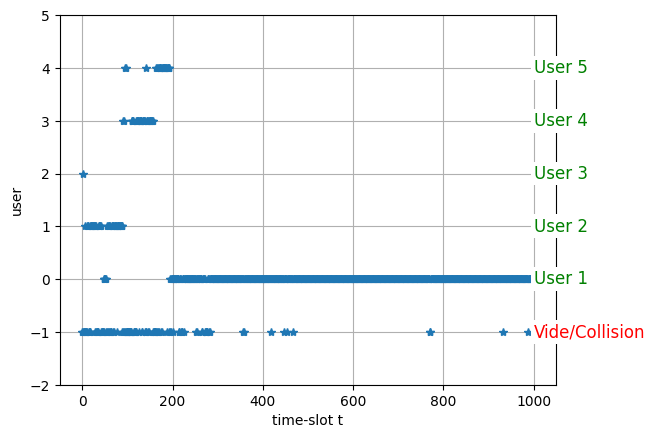

In [33]:
plt.plot(np.arange(1000), user_vec[:1000], '*')
plt.ylabel('user')
plt.xlabel('time-slot t')
plt.ylim(-2, 5)

plt.text(1000, 0, f'User 1', va='center', fontsize=12, color='green',  bbox=dict(facecolor='white', edgecolor='none', pad=2))
plt.text(1000, 1, f'User 2', va='center', fontsize=12, color='green',  bbox=dict(facecolor='white', edgecolor='none', pad=2))
plt.text(1000, 2, f'User 3', va='center', fontsize=12, color='green',  bbox=dict(facecolor='white', edgecolor='none', pad=2))
plt.text(1000, 3, f'User 4', va='center', fontsize=12, color='green',  bbox=dict(facecolor='white', edgecolor='none', pad=2))
plt.text(1000, 4, f'User 5', va='center', fontsize=12, color='green',  bbox=dict(facecolor='white', edgecolor='none', pad=2))
plt.text(1000, -1, f'Vide/Collision', va='center', fontsize=12, color='red',  bbox=dict(facecolor='white', edgecolor='none', pad=2))

plt.grid()
plt.show()



**Les points du graphique en -1 correspondent à une absence de transmission ou à une collision.**



7. Illustrez avec une courbe le débit total du systéme en fonction de $p0$, pour $p0 = [0,1]$ (le pas de simulation est $0.1$), et pour $N = 5$, $N = 30$. Quels sont vos conclusions, en observant les plots?

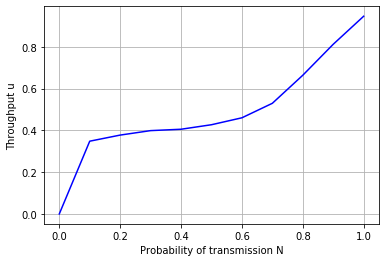

In [ ]:
plt.plot(p_vec, throughput_A_p, 'b-')
plt.xlabel('Probability of transmission N')
plt.ylabel('Throughput u')
plt.grid()
plt.show()

your conclusions here

END